<a href="https://colab.research.google.com/github/sagarppatil020504/Echno_Flex/blob/main/gold_price_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%bash
pip install transformers torch numpy pandas
pip install newsapi-python
pip install requests


In [ ]:
!git config --global user.email "sagarppatil020504@gmail.com"
!git config --global user.name "sagarppatil020504"
!git clone https://github.com/sagarppatil020504/Echno_Flex.git
!cp /content/your-notebook.ipynb your-repository-name/
%cd your-repository-name/
!git add .
!git commit -m "Commit message"
!git push origin main

In [ ]:
from newsapi import NewsApiClient
from transformers import pipeline

# Initialize News API (replace 'your_api_key' with your News API key)
newsapi = NewsApiClient(api_key='6685d1357e634d04819fd7c35134ec03')

def get_gold_related_news():
    # Fetch gold-related news
    articles = newsapi.get_everything(q='gold price', language='en', sort_by='relevancy', page_size=50)
    headlines = [article['title'] for article in articles['articles']]
    return headlines

# Fetch news headlines
headlines = get_gold_related_news()
print("Headlines:", headlines)


# Load the BERT sentiment analysis model
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def analyze_sentiment_with_bert(headlines):
    sentiment_scores = []
    for headline in headlines:
        result = sentiment_analyzer(headline)
        # Assign +1 for positive, -1 for negative
        sentiment = 1 if result[0]['label'] == 'POSITIVE' else -1
        sentiment_scores.append(sentiment * result[0]['score'])  # Multiply by confidence score
    return sum(sentiment_scores) / len(sentiment_scores) if sentiment_scores else 0

# Analyze sentiment
sentiment_score = analyze_sentiment_with_bert(headlines)
print(f"Sentiment Score: {sentiment_score}")

# Adjust predictions based on sentiment
adjustment_factor = 0.01  # Adjust prices by 1% for strong sentiment
adjusted_prices = []


Headlines: ['We’re Costco Guys, Of Course We Got the $45 Gift Card With Our 1-Year Gold Star Membership', 'The Apple Watch Series 10 is back down to its Black Friday price', 'World champion Price knocks out Mateus in mismatch', 'The Top-Selling 27-Inch HP Monitor Is at Its Lowest Price Ever as the Year Comes to a Close', 'Geekom A8 Mini PC Is Now at Its Lowest Price, Thanks to a Gizmodo Exclusive Code for Christmas', "Here are the deals the 'AI arms race' could drive in 2025, according to 4 bankers from Goldman Sachs, BofA, and Axom Partners", '[Removed]', '42 Best Cyber Monday Camera Deals (2024)', 'I drove a $211,000 Porsche Taycan GTS EV. It was as fun to drive as it was pricey.', "Apple Watch Series 10 Hits All-Time Low Prices in New Year's Sale, Starting at $329", 'Price of bitcoin falls more than 10%', 'Gollum would murder hobbitses to get this 43% OFF smart ring lightning deal before Cyber Monday ends', 'Best Cyber Monday VPN Deals: Which Ones Are the Cheapest and the Best? ($2/

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


Sentiment Score: -0.23751528739929198


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 309ms/step - loss: 0.0158 - val_loss: 0.0026
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 158ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 140ms/step - loss: 8.8217e-04 - val_loss: 0.0036
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 242ms/step - loss: 6.8955e-04 - val_loss: 0.0037
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 143ms/step - loss: 6.6812e-04 - val_loss: 0.0056
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step
RMSE: 129.81125952598856


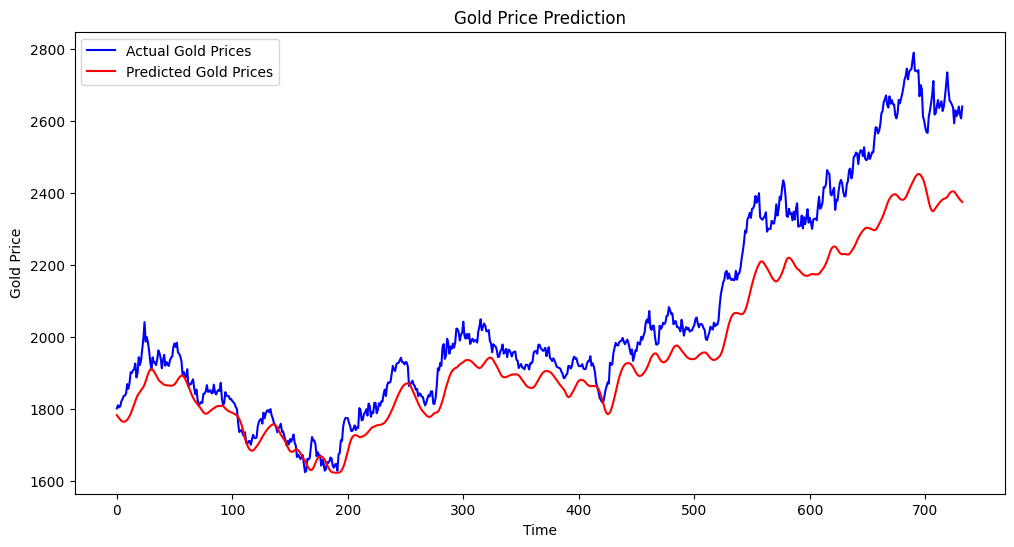

Model saved successfully!


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import yfinance as yf
import matplotlib.pyplot as plt
import time
# -------------------------------------
# Step 1: Data Collection
# -------------------------------------

# Fetch historical gold price data
def get_gold_price_data(start_date, end_date):
    gold_data = yf.download('GC=F', start=start_date, end=end_date)  # 'GC=F' is the Yahoo Finance ticker for gold futures
    gold_data['Date'] = gold_data.index
    gold_data.reset_index(drop=True, inplace=True)
    return gold_data

# Fetch data
start_date = "2010-01-01"
end_date = time.strftime("%Y-%m-%d",time.localtime())
gold_data = get_gold_price_data(start_date, end_date)

# -------------------------------------
# Step 2: Feature Engineering
# -------------------------------------

# Create technical indicators
gold_data['SMA_20'] = gold_data['Close'].rolling(window=20).mean()  # Simple Moving Average (20 days)
gold_data['SMA_50'] = gold_data['Close'].rolling(window=50).mean()  # Simple Moving Average (50 days)
gold_data['RSI'] = 100 - (100 / (1 + gold_data['Close'].pct_change().rolling(window=14).mean() /
                                      gold_data['Close'].pct_change().rolling(window=14).std()))
gold_data['MACD'] = gold_data['Close'].ewm(span=12).mean() - gold_data['Close'].ewm(span=26).mean()

# Drop NaN values (caused by rolling calculations)
gold_data.dropna(inplace=True)

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(gold_data[['Close', 'SMA_20', 'SMA_50', 'RSI', 'MACD']])

# Create time-series data for the LSTM model
def create_sequences(data, seq_length=60):
    x, y = [], []
    for i in range(seq_length, len(data)):
        x.append(data[i-seq_length:i])
        y.append(data[i, 0])  # Predict the 'Close' price
    return np.array(x), np.array(y)

seq_length = 60
x, y = create_sequences(scaled_data, seq_length)

# Split into training and testing datasets
train_size = int(len(x) * 0.8)
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# -------------------------------------
# Step 3: Build the LSTM Model
# -------------------------------------

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)  # Predict a single value (gold price)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(x_train, y_train, batch_size=32, epochs=5, validation_data=(x_test, y_test))

# -------------------------------------
# Step 4: Evaluate the Model
# -------------------------------------

# Predict on the test dataset
predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(np.concatenate((predicted_prices, np.zeros((predicted_prices.shape[0], 4))), axis=1))[:, 0]


#added set to modify the predicted values
for price in predicted_prices:
    if sentiment_score > 0.2:  # Positive sentiment
        adjusted_price = price * (1 + adjustment_factor * sentiment_score)
    elif sentiment_score < -0.2:  # Negative sentiment
        adjusted_price = price * (1 + adjustment_factor * sentiment_score)
    else:  # Neutral sentiment
        adjusted_price = price
    adjusted_prices.append(adjusted_price)

# Actual prices
actual_prices = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 4))), axis=1))[:, 0]

# Calculate RMSE
rmse = np.sqrt(np.mean((predicted_prices - actual_prices) ** 2))
print(f"RMSE: {rmse}")

# -------------------------------------
# Step 5: Visualization
# -------------------------------------

plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label="Actual Gold Prices", color='blue')
plt.plot(predicted_prices, label="Predicted Gold Prices", color='red')
plt.title("Gold Price Prediction")
plt.xlabel("Time")
plt.ylabel("Gold Price")
plt.legend()
plt.show()

# -------------------------------------
# Step 6: Save the Model
# -------------------------------------

# Save the model in HDF5 format
model.save("lstm_gold_price_model.h5")
print("Model saved successfully!")


In [ ]:
# #TESTING THE DATA WITH RECENT GRAPH AND PREDICTING THE GROWTH OR THE FALL OF GOLD
# # Fetch data of 20 days back
# from datetime import datetime, timedelta
# start_date = (datetime.now() - timedelta(days=100)).strftime("%Y-%m-%d")
# end_date = time.strftime("%Y-%m-%d",time.localtime())
# gold_data = get_gold_price_data(start_date, end_date)

# # -------------------------------------
# # Step 2: Feature Engineering
# # -------------------------------------

# # Create technical indicators
# gold_data['SMA_20'] = gold_data['Close'].rolling(window=20).mean()  # Simple Moving Average (20 days)
# gold_data['SMA_50'] = gold_data['Close'].rolling(window=50).mean()  # Simple Moving Average (50 days)
# print(gold_data)
# gold_data.dropna(inplace=True)
# print(gold_data)
# # Normalize the data using MinMaxScaler
# scaler = MinMaxScaler()
# scaled_data = scaler.fit_transform(gold_data[['Close', 'SMA_20', 'SMA_50']])

# #Predict on the test dataset
# predicted_prices = model.predict(scaled_data)
# predicted_prices = scaler.inverse_transform(np.concatenate((predicted_prices, np.zeros((predicted_prices.shape[0], 4))), axis=1))[:, 0]


# #added set to modify the predicted values
# for price in predicted_prices:
#     if sentiment_score > 0.2:  # Positive sentiment
#         adjusted_price = price * (1 + adjustment_factor * sentiment_score)
#     elif sentiment_score < -0.2:  # Negative sentiment
#         adjusted_price = price * (1 + adjustment_factor * sentiment_score)
#     else:  # Neutral sentiment
#         adjusted_price = price
#     adjusted_prices.append(adjusted_price)

# # Actual prices
# actual_prices = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 2))), axis=1))[:, 0]

# # Calculate RMSE
# rmse = np.sqrt(np.mean((predicted_prices - actual_prices) ** 2))
# print(f"RMSE: {rmse}")

# # -------------------------------------
# # Step 5: Visualization
# # -------------------------------------

# plt.figure(figsize=(12, 6))
# plt.plot(actual_prices, label="Actual Gold Prices", color='blue')
# plt.plot(predicted_prices, label="Predicted Gold Prices", color='red')
# plt.title("Gold Price Prediction")
# plt.xlabel("Time")
# plt.ylabel("Gold Price")
# plt.legend()
# plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import yfinance as yf
import matplotlib.pyplot as plt
import time
# -------------------------------------
# Step 1: Data Collection
# -------------------------------------

# Fetch historical gold price data
def get_gold_price_data(start_date, end_date):
    gold_data = yf.download('GC=F', start=start_date, end=end_date)  # 'GC=F' is the Yahoo Finance ticker for gold futures
    gold_data['Date'] = gold_data.index
    gold_data.reset_index(drop=True, inplace=True)
    return gold_data

# Fetch data
start_date = "2010-01-01"
end_date = time.strftime("%Y-%m-%d",time.localtime())
gold_data = get_gold_price_data(start_date, end_date)

# -------------------------------------
# Step 2: Feature Engineering
# -------------------------------------

# Create technical indicators
gold_data['SMA_20'] = gold_data['Close'].rolling(window=20).mean()  # Simple Moving Average (20 days)
gold_data['SMA_50'] = gold_data['Close'].rolling(window=50).mean()  # Simple Moving Average (50 days)
gold_data['RSI'] = 100 - (100 / (1 + gold_data['Close'].pct_change().rolling(window=14).mean() /
                                      gold_data['Close'].pct_change().rolling(window=14).std()))
gold_data['MACD'] = gold_data['Close'].ewm(span=12).mean() - gold_data['Close'].ewm(span=26).mean()

# Drop NaN values (caused by rolling calculations)
gold_data.dropna(inplace=True)


[*********************100%***********************]  1 of 1 completed


In [ ]:
# Define the number of days into the future to predict
future_days = 5

# Create a new column for the target, shifted by `future_days`
gold_data['Future_Price'] = gold_data['Close'].shift(-future_days)
print(gold_data)

# Drop the last `future_days` rows (since they have no future data)
gold_data.dropna(inplace=True)
print(gold_data)

# Update features and labels
features = gold_data[['Close', 'SMA_20', 'SMA_50', 'RSI', 'MACD']].values
labels = gold_data['Future_Price'].values

# Normalize the features
scaled_features = scaler.fit_transform(features)

# Create sequences for LSTM
x, y = create_sequences(scaled_features, seq_length)

# Update the dataset for training and testing
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
# Predict future prices
predicted_future_prices = model.predict(x_test)

# Reverse scaling for predictions and actual values
predicted_prices = scaler.inverse_transform(
    np.concatenate((predicted_future_prices, np.zeros((predicted_future_prices.shape[0], 4))), axis=1)
)[:, 0]

actual_prices = scaler.inverse_transform(
    np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 4))), axis=1)
)[:, 0]

# Calculate RMSE for future predictions
rmse = np.sqrt(np.mean((predicted_prices - actual_prices) ** 2))
print(f"RMSE for Future Predictions: {rmse}")
# Predict future prices based on the latest data
future_predictions = []
current_sequence = scaled_features[-seq_length:]  # Start with the latest sequence

for _ in range(future_days):
    prediction = model.predict(current_sequence[np.newaxis, :, :])[0]
    future_predictions.append(prediction)
    # Update the sequence with the new prediction# Pad the prediction with zeros to match the number of features (5 in this case)
    padded_prediction = np.zeros((1, current_sequence.shape[1]))  # Shape (1, 5)
    padded_prediction[0, 0] = prediction  # Set the 'Close' price as the prediction

    # Append the padded prediction to the current sequence
    current_sequence = np.append(current_sequence[1:], padded_prediction, axis=0)


# Reverse scaling for predictions
future_predictions = scaler.inverse_transform(
    np.concatenate((np.array(future_predictions), np.zeros((len(future_predictions), 4))), axis=1)
)[:, 0]

print(f"Future Gold Price Predictions: {future_predictions}")


Price     Adj Close        Close         High          Low         Open  \
Ticker         GC=F         GC=F         GC=F         GC=F         GC=F   
49      1122.199951  1122.199951  1127.000000  1114.500000  1122.199951   
50      1124.000000  1124.000000  1131.400024  1118.000000  1124.000000   
51      1127.400024  1127.400024  1127.800049  1121.099976  1127.400024   
52      1107.400024  1107.400024  1107.400024  1107.400024  1107.400024   
53      1099.300049  1099.300049  1099.300049  1099.300049  1099.300049   
...             ...          ...          ...          ...          ...   
3766    2620.000000  2620.000000  2620.000000  2609.500000  2613.000000   
3767    2638.800049  2638.800049  2638.800049  2627.899902  2628.500000   
3768    2617.199951  2617.199951  2617.699951  2616.399902  2617.699951   
3769    2606.100098  2606.100098  2626.899902  2597.000000  2620.699951   
3770    2639.300049  2639.300049  2642.000000  2614.300049  2620.000000   

Price  Volume       Date

<ipython-input-8-9fb3a229a734>:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  padded_prediction[0, 0] = prediction  # Set the 'Close' price as the prediction


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Future Gold Price Predictions: [2389.34716375 2354.65492857 2296.13744239 2225.43249449 2143.91442139]


In [ ]:
# from google.colab import drive
# import pandas as pd

# # Mount Google Drive
# drive.mount('/content/drive')

# # Save a DataFrame
# data = {actual_prices, sentiment_score ,predicted_prices ,future_predictions}
# df = pd.DataFrame(data)
# df.to_csv('/content/drive/My Drive/sample_data.csv', index=False)

# print("Data saved to Google Drive!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


TypeError: unhashable type: 'numpy.ndarray'

In [ ]:
# from google.colab import drive
# import pandas as pd

# # Mount Google Drive
# drive.mount('/content/drive')

# # Convert NumPy arrays to lists before creating the dictionary
# data = {
#     'actual_prices': actual_prices.tolist(),  # Convert to list
#     'sentiment_score': sentiment_score,
#     'predicted_prices': predicted_prices.tolist(),  # Convert to list
#     'future_predictions': future_predictions.tolist()  # Convert to list
# }

# df = pd.DataFrame(data)
# df.to_csv('/content/drive/My Drive/gold_data.csv', index=False)

# print("Data saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ValueError: All arrays must be of the same length

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Convert NumPy arrays to lists before creating the dictionary
# Get the minimum length among the arrays
min_length = min(len(actual_prices), len(predicted_prices), len(future_predictions))

# Slice the arrays to the minimum length
data = {
    'actual_prices': actual_prices[:min_length].tolist(),  # Convert to list and slice
    'sentiment_score': [sentiment_score] * min_length,  # Repeat sentiment score to match length
    'predicted_prices': predicted_prices[:min_length].tolist(),  # Convert to list and slice
    'future_predictions': future_predictions[:min_length].tolist()  # Convert to list and slice

}

df = pd.DataFrame(data)
df.to_csv('/content/drive/My Drive/gold_data.csv', index=False)

print("Data saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data saved to Google Drive!


In [ ]:
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
import pandas as pd

# Define time ranges
# Assuming start_date and end_date are defined elsewhere
actual_time = pd.date_range(start=start_date, end=end_date) # Corrected end parameter
predicted_time = pd.date_range(start=end_date, end=end_date)
future_time = pd.date_range(start=end_date,end=end_date)

# Visualization
plt.figure(figsize=(14, 7))
plt.plot(len(actual_prices) ,actual_prices, label="Actual Gold Prices", color='blue')
plt.plot(len(predicted_prices), predicted_prices, label="Predicted Gold Prices", color='red', linestyle='dashed')
plt.plot(len(future_predictions), future_predictions, label="Future Predicted Prices", color='green')
plt.title("Gold Price Prediction with Sentiment Adjustment Using BERT")
plt.xlabel("Time")
plt.ylabel("Gold Price")
plt.legend()
plt.grid(True)
plt.show()

# Visualization
plt.figure(figsize=(14, 7))
plt.plot(actual_time, actual_prices, label="Actual Gold Prices", color='blue')
plt.plot(predicted_time, predicted_prices, label="Predicted Gold Prices", color='red', linestyle='dashed')
plt.plot(future_time, future_predictions, label="Future Predicted Prices", color='green')
plt.title("Gold Price Prediction with Sentiment Adjustment Using BERT")
plt.xlabel("Time")
plt.ylabel("Gold Price")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from google.colab import drive
import pandas as pd
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
import pandas as pd

# Define time ranges
# Assuming start_date and end_date are defined elsewhere
actual_time = pd.date_range(start=start_date, end=end_date) # Corrected end parameter
predicted_time = pd.date_range(start=end_date, end=end_date)
future_time = pd.date_range(start=end_date,end=end_date)

# Mount Google Drive
drive.mount('/content/drive')

# Convert NumPy arrays to lists before creating the dictionary
# Get the minimum length among the arrays
min_length = min(len(actual_time), len(predicted_time), len(future_time))

# Slice the arrays to the minimum length
data = {
    'actual_time':actual_time[:min_length].tolist(),  # Convert to list and slice
    # 'sentiment_score': [sentiment_score] * min_length,  # Repeat sentiment score to match length
    'predicted_time': predicted_time[:min_length].tolist(),  # Convert to list and slice
    'future_time': future_time[:min_length].tolist()  # Convert to list and slice

}

df = pd.DataFrame(data)
df.to_csv('/content/drive/My Drive/time_data.csv', index=False)

print("Data saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data saved to Google Drive!


In [ ]:
# CONNECT TO FLASK API
import requests

# Replace with your ngrok URL
flask_url = "http://127.0.0.1:5000"

# Example data to send to your Flask API
data = { actual_time, actual_prices,predicted_time, predicted_prices,future_time, future_predictions    # Add other necessary inputs
        }

# Send a POST request to the Flask API
response = requests.post(flask_url, json=data)

# Get the prediction result
if response.status_code == 200:
    prediction = response.json()
    print("Prediction:", prediction)
else:
    print("Error:", response.text)



In [ ]:
#FINAL CODE
from newsapi import NewsApiClient
from transformers import pipeline
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import yfinance as yf
import matplotlib.pyplot as plt
import time
from datetime import timedelta, datetime

# Initialize News API (replace with your News API key)
newsapi = NewsApiClient(api_key='6685d1357e634d04819fd7c35134ec03')

# Function to fetch gold-related news headlines
def get_gold_related_news():
    articles = newsapi.get_everything(q='gold price', language='en', sort_by='relevancy', page_size=50)
    return [article['title'] for article in articles['articles']]

# Load sentiment analysis model
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Analyze sentiment of headlines
def analyze_sentiment(headlines):
    sentiment_scores = []
    for headline in headlines:
        result = sentiment_analyzer(headline)
        sentiment = 1 if result[0]['label'] == 'POSITIVE' else -1
        sentiment_scores.append(sentiment * result[0]['score'])
    return sum(sentiment_scores) / len(sentiment_scores) if sentiment_scores else 0

# Fetch historical gold price data
def get_gold_price_data(start_date, end_date):
    gold_data = yf.download('GC=F', start=start_date, end=end_date)  # Yahoo Finance ticker for gold futures
    gold_data['Date'] = gold_data.index
    gold_data.reset_index(drop=True, inplace=True)
    return gold_data

# Create sequences for LSTM
def create_sequences(data, seq_length=60):
    x, y = [], []
    for i in range(seq_length, len(data)):
        x.append(data[i - seq_length:i])
        y.append(data[i, 0])  # Predict the 'Close' price
    return np.array(x), np.array(y)

# Main process
def main():
    # Step 1: Fetch news headlines and analyze sentiment
    headlines = get_gold_related_news()
    sentiment_score = analyze_sentiment(headlines)
    adjustment_factor = 0.01  # Adjust prices by 1% for sentiment

    # Step 2: Fetch historical gold price data
    start_date = "2010-01-01"
    end_date = time.strftime("%Y-%m-%d", time.localtime())
    gold_data = get_gold_price_data(start_date, end_date)

    # Feature engineering
    gold_data['SMA_20'] = gold_data['Close'].rolling(window=20).mean()
    gold_data['SMA_50'] = gold_data['Close'].rolling(window=50).mean()
    gold_data['RSI'] = 100 - (100 / (1 + gold_data['Close'].pct_change().rolling(window=14).mean() /
                                      gold_data['Close'].pct_change().rolling(window=14).std()))
    gold_data['MACD'] = gold_data['Close'].ewm(span=12).mean() - gold_data['Close'].ewm(span=26).mean()
    gold_data.dropna(inplace=True)

    # Prepare data for LSTM
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(gold_data[['Close', 'SMA_20', 'SMA_50', 'RSI', 'MACD']])
    seq_length = 60
    x, y = create_sequences(scaled_data, seq_length)

    # Split into training and testing datasets
    train_size = int(len(x) * 0.8)
    x_train, x_test = x[:train_size], x[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Step 3: Build the LSTM model
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(x_train, y_train, batch_size=32, epochs=5, validation_data=(x_test, y_test))

    # Step 4: Predict and adjust prices based on sentiment
    predicted_prices = model.predict(x_test)
    predicted_prices = scaler.inverse_transform(
        np.concatenate((predicted_prices, np.zeros((predicted_prices.shape[0], 4))), axis=1)
    )[:, 0]
    adjusted_prices = [
        price * (1 + adjustment_factor * sentiment_score) if abs(sentiment_score) > 0.2 else price
        for price in predicted_prices
    ]

    # Calculate RMSE
    actual_prices = scaler.inverse_transform(
        np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 4))), axis=1)
    )[:, 0]
    rmse = np.sqrt(np.mean((predicted_prices - actual_prices) ** 2))
    print(f"RMSE: {rmse}")

    # Step 5: Predict future prices
    future_days = 5
    current_sequence = scaled_data[-seq_length:]
    future_predictions = []
    for _ in range(future_days):
        prediction = model.predict(current_sequence[np.newaxis, :, :])[0]
        future_predictions.append(prediction)
        padded_prediction = np.zeros((1, current_sequence.shape[1]))
        padded_prediction[0, 0] = prediction
        current_sequence = np.append(current_sequence[1:], padded_prediction, axis=0)
    future_predictions = scaler.inverse_transform(
        np.concatenate((np.array(future_predictions), np.zeros((len(future_predictions), 4))), axis=1)
    )[:, 0]

    # Step 6: Visualization
    plt.figure(figsize=(14, 7))
    plt.plot(actual_prices, label="Actual Gold Prices", color='blue')
    plt.plot(predicted_prices, label="Predicted Gold Prices", color='red', linestyle='dashed')
    plt.plot(range(len(actual_prices), len(actual_prices) + future_days), future_predictions, label="Future Predictions", color='green')
    plt.title("Gold Price Prediction with Sentiment Adjustment")
    plt.xlabel("Time")
    plt.ylabel("Gold Price")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Step 7: Save the Model
    model.save("lstm_gold_price_model.h5")
    print("Model saved successfully!")

# Run the program
if __name__ == "__main__":
    main()
